# 第 6 课：封装声学前端，并与 Librosa 对照

前五课已经走完 `WAV → Log-Mel`。这一课把散落步骤封装成可复用函数，并学习一个工程上非常重要的事实：两个实现都叫 Log-Mel，结果仍可能不同，因为默认参数不同。

目标：会读参数、会检查 shape、会定位差异，不把‘数值不一样’立刻当成算法错误。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | 声音与声学特征 |
| 建议投入 | 2～4 小时，可分 2～3 次完成 |
| 前置要求 | 完成第 5 课；如果前测低于 2/3，先回看上一课小结 |
| 本课核心 | 声学前端封装、数值一致性、参数契约 |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：声学前端封装、数值一致性、参数契约。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


<!-- course-bridge-v3 -->
## 知识接力：先取回旧知识，再进入本课

### 3 分钟闭卷回忆

在新 Markdown cell 中回答，**不要先翻前文**：真实 WAV 的输入审计；分帧/STFT/Mel 每一步 shape；dB 参考值和数值下限。

- 三项都能用“含义 + 单位/shape + 一个数字例子”回答：进入本课。
- 能回答两项：学习本课，但把缺口记入 `LEARNING_LOG.md`。
- 只能回答零到一项：先回到 [音频基础 6](音频基础_06_真实WAV读取试听与输入审计.ipynb)与主线第 1～5 课，做一次最小实验；不要靠继续看新术语掩盖断点。

### 本课接口契约

```text
输入：明确契约的波形、采样率和前端配置
  ↓ 本课要学会的变换、状态或判断
输出：可测试、可与 Librosa 数值对照的 Log-Mel 前端
```

学完后必须能解释：输入的哪个单位/shape/状态若丢失，会让输出“仍能运行却语义错误”。


In [1]:
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import ipywidgets as widgets
from IPython.display import Audio, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
print('librosa version:',librosa.__version__)

librosa version: 1.0.0


## 1. 先固定参数：可复现的第一步

不要只写‘提取 Log-Mel’，还要记录采样率、帧长、帧移、FFT 点数、Mel 数量、最低/最高频率、是否 center、Mel 公式和归一化方式。

In [2]:
@dataclass(frozen=True)
class FrontendConfig:
    sample_rate: int = 8000
    frame_ms: float = 25.0
    hop_ms: float = 10.0
    n_fft: int = 200
    n_mels: int = 40
    fmin: float = 0.0
    fmax: float | None = None
    eps: float = 1e-10

    @property
    def frame_size(self):
        return round(self.sample_rate*self.frame_ms/1000)

    @property
    def hop_size(self):
        return round(self.sample_rate*self.hop_ms/1000)

cfg=FrontendConfig()
print(cfg)
print('frame samples:',cfg.frame_size)
print('hop samples:',cfg.hop_size)

FrontendConfig(sample_rate=8000, frame_ms=25.0, hop_ms=10.0, n_fft=200, n_mels=40, fmin=0.0, fmax=None, eps=1e-10)
frame samples: 200
hop samples: 80


这里暂时令 `n_fft=frame_size=200`，目的是让手写实现和 Librosa 更容易严格对齐。之后再回到常见的 256/512 点 FFT。

## 2. 读取并检查输入

声学前端最先要检查的不是 FFT，而是采样率、声道数、数据类型和幅度范围。

In [3]:
audio,sr=sf.read(ROOT/'data'/'0_jackson_0.wav',dtype='float32')
if audio.ndim>1: audio=audio.mean(axis=1)
print('shape:',audio.shape)
print('dtype:',audio.dtype)
print('sample rate:',sr)
print('min/max:',float(audio.min()),float(audio.max()))
assert sr==cfg.sample_rate,'采样率必须与配置一致'
assert audio.ndim==1,'本课前端要求单声道'
display(Audio(audio,rate=sr))

shape: (5148,)
dtype: float32
sample rate: 8000
min/max: -0.660919189453125 0.737396240234375


### 练习 1

1. 为什么不能默默把 16 kHz 配置用于 8 kHz 音频？
2. 双声道音频进入当前函数前需要怎样处理？
3. `assert` 的作用是什么？

## 3. 封装手写前端

为了和 Librosa 的 `htk=True, norm=None` 对齐，这里使用 HTK Mel 公式和峰值为 1 的三角滤波器。输出统一为 `(time, mel)`。

In [4]:
def hz_to_mel_htk(hz):
    return 2595*np.log10(1+np.asarray(hz)/700)

def mel_to_hz_htk(mel):
    return 700*(10**(np.asarray(mel)/2595)-1)

def manual_mel_bank(cfg):
    fmax=cfg.sample_rate/2 if cfg.fmax is None else cfg.fmax
    mel_points=np.linspace(hz_to_mel_htk(cfg.fmin),hz_to_mel_htk(fmax),cfg.n_mels+2)
    hz_points=mel_to_hz_htk(mel_points)
    fft_freqs=np.fft.rfftfreq(cfg.n_fft,1/cfg.sample_rate)
    bank=np.zeros((cfg.n_mels,len(fft_freqs)))
    for m in range(cfg.n_mels):
        left,center,right=hz_points[m:m+3]
        rise=(fft_freqs-left)/(center-left)
        fall=(right-fft_freqs)/(right-center)
        bank[m]=np.maximum(0,np.minimum(rise,fall))
    return bank

def manual_logmel(audio,cfg):
    if len(audio)<cfg.frame_size:
        raise ValueError('音频短于一帧')
    starts=np.arange(0,len(audio)-cfg.frame_size+1,cfg.hop_size)
    frames=np.stack([audio[s:s+cfg.frame_size] for s in starts])
    windowed=frames*np.hanning(cfg.frame_size)[None,:]
    spectrum=np.fft.rfft(windowed,n=cfg.n_fft,axis=1)
    power=np.abs(spectrum)**2
    mel_power=power@manual_mel_bank(cfg).T
    logmel=np.log(np.maximum(mel_power,cfg.eps))
    return logmel,starts/cfg.sample_rate

manual_feature,manual_times=manual_logmel(audio,cfg)
print('manual shape:',manual_feature.shape)
print('全部有限值:',np.isfinite(manual_feature).all())

manual shape: (62, 40)
全部有限值: True


## 4. 使用 Librosa 提取同样的特征

必须显式指定：`center=False`、`power=2`、`htk=True`、`norm=None`。Librosa 返回 `(mel,time)`，所以转置为 `(time,mel)`。

In [5]:
librosa_mel=librosa.feature.melspectrogram(
    y=audio,sr=cfg.sample_rate,n_fft=cfg.n_fft,
    win_length=cfg.frame_size,hop_length=cfg.hop_size,
    window='hann',center=False,power=2.0,
    n_mels=cfg.n_mels,fmin=cfg.fmin,fmax=cfg.fmax,
    htk=True,norm=None,
)
librosa_feature=np.log(np.maximum(librosa_mel.T,cfg.eps))
print('Librosa 原始 shape (mel,time):',librosa_mel.shape)
print('转置后 shape (time,mel):',librosa_feature.shape)
print('shape 相同:',manual_feature.shape==librosa_feature.shape)

Librosa 原始 shape (mel,time): (40, 62)
转置后 shape (time,mel): (62, 40)
shape 相同: True


## 5. 数值对比：为什么仍可能有小差异？

NumPy 的 `np.hanning(N)` 使用对称 Hann 窗；Librosa/Scipy 的 FFT 分析窗默认通常是周期形式。只差一个窗函数约定，也会让结果不完全相同。先画差值，再让窗定义严格对齐。

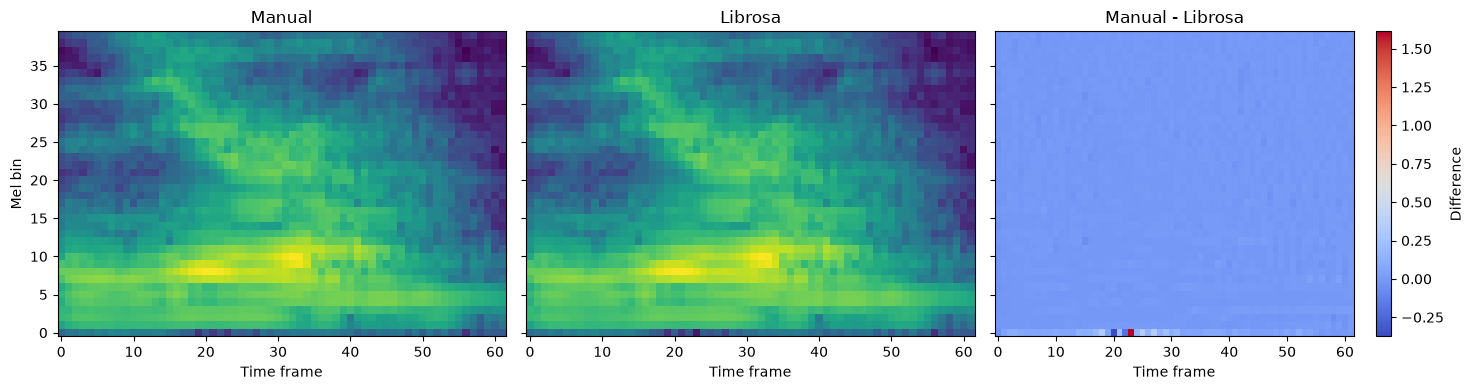

最大绝对差: 1.6130442227508386
平均绝对差: 0.010107010855549239


In [6]:
difference=manual_feature-librosa_feature
fig,axes=plt.subplots(1,3,figsize=(15,4),sharex=True,sharey=True)
im0=axes[0].imshow(manual_feature.T,origin='lower',aspect='auto'); axes[0].set_title('Manual')
im1=axes[1].imshow(librosa_feature.T,origin='lower',aspect='auto'); axes[1].set_title('Librosa')
im2=axes[2].imshow(difference.T,origin='lower',aspect='auto',cmap='coolwarm'); axes[2].set_title('Manual - Librosa')
for ax in axes: ax.set_xlabel('Time frame')
axes[0].set_ylabel('Mel bin'); fig.colorbar(im2,ax=axes[2],label='Difference')
plt.tight_layout(); plt.show()
print('最大绝对差:',float(np.max(np.abs(difference))))
print('平均绝对差:',float(np.mean(np.abs(difference))))

In [7]:
from scipy.signal import get_window

def manual_logmel_matched(audio,cfg):
    starts=np.arange(0,len(audio)-cfg.frame_size+1,cfg.hop_size)
    frames=np.stack([audio[s:s+cfg.frame_size] for s in starts])
    # fftbins=True：周期 Hann，与频谱分析库的约定对齐
    window=get_window('hann',cfg.frame_size,fftbins=True)
    spectrum=np.fft.rfft(frames*window[None,:],n=cfg.n_fft,axis=1)
    power=np.abs(spectrum)**2
    mel_power=power@manual_mel_bank(cfg).T
    return np.log(np.maximum(mel_power,cfg.eps))

matched=manual_logmel_matched(audio,cfg)
matched_diff=matched-librosa_feature
print('对齐后的最大绝对差:',float(np.max(np.abs(matched_diff))))
print('对齐后的平均绝对差:',float(np.mean(np.abs(matched_diff))))
print('近似相同:',np.allclose(matched,librosa_feature,rtol=1e-4,atol=1e-5))

对齐后的最大绝对差: 6.11049244980677e-07
对齐后的平均绝对差: 1.1536948554801936e-07
近似相同: True


### 关键结论

比较实现时必须把所有约定对齐：窗函数是否周期化、center、padding、Mel 公式、滤波器归一化、power 指数、log 底数、epsilon 和输出维度顺序。只比较函数名称是不够的。

## 6. `center=True` 到底改变什么？

Librosa 默认 `center=True`：在音频两端 padding，使第 t 帧中心对齐 `t*hop_length`。`center=False`：第 t 帧从 `t*hop_length` 开始。它们的帧数和边缘特征会不同。

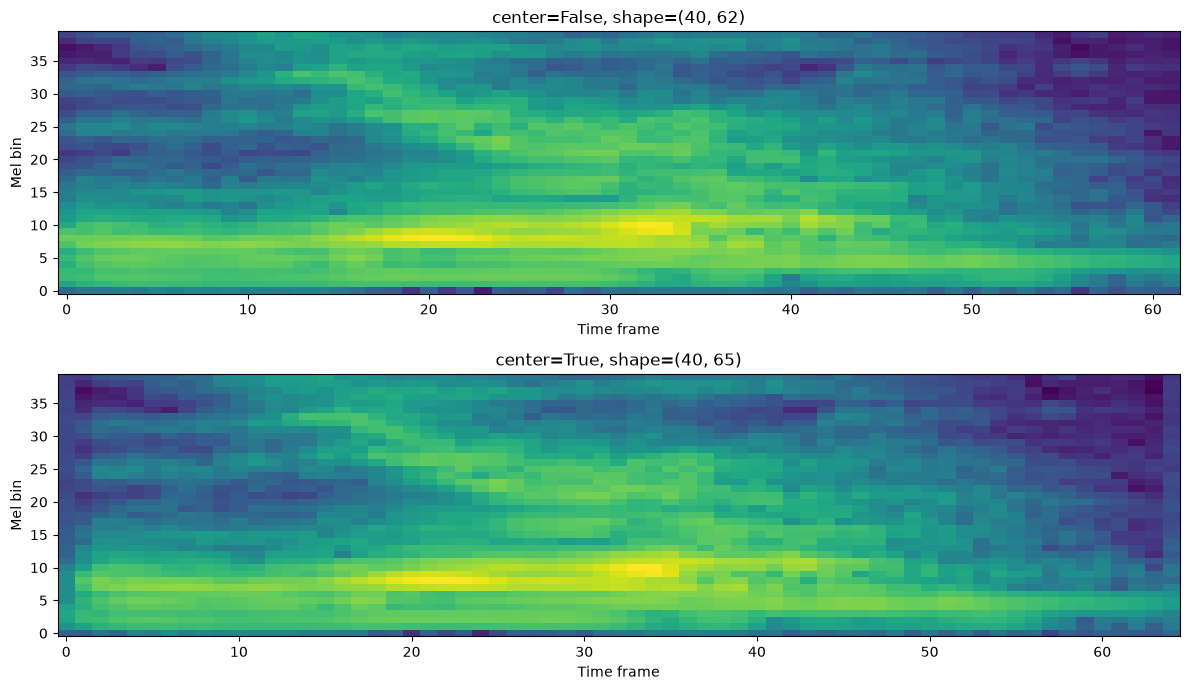

In [8]:
def librosa_frontend(center):
    mel=librosa.feature.melspectrogram(
        y=audio,sr=cfg.sample_rate,n_fft=cfg.n_fft,win_length=cfg.frame_size,
        hop_length=cfg.hop_size,window='hann',center=center,pad_mode='constant',
        power=2,n_mels=cfg.n_mels,htk=True,norm=None)
    return librosa.power_to_db(mel,ref=np.max)

without_center=librosa_frontend(False)
with_center=librosa_frontend(True)
fig,axes=plt.subplots(2,1,figsize=(12,7),sharey=True)
axes[0].imshow(without_center,origin='lower',aspect='auto',vmin=-80,vmax=0); axes[0].set_title(f'center=False, shape={without_center.shape}')
axes[1].imshow(with_center,origin='lower',aspect='auto',vmin=-80,vmax=0); axes[1].set_title(f'center=True, shape={with_center.shape}')
for ax in axes: ax.set_ylabel('Mel bin'); ax.set_xlabel('Time frame')
plt.tight_layout(); plt.show()

### 练习 2

1. 哪种设置产生更多时间帧？
2. `center=True` 增加的是实录语音还是人工 padding？
3. 流式 ASR 为什么常偏向 `center=False`？提示：实时系统不能依赖未来样本来居中当前帧。

## 7. Librosa 默认 Mel 与我们上一课的 HTK Mel 为什么不同？

Librosa 默认 `htk=False, norm='slaney'`。它使用 Slaney 风格 Mel，并按频带宽度做面积归一化。上一课手写的是 HTK 公式、三角形峰值为 1。两者都叫 Mel filterbank，但数值约定不同。

<USER_HOME>\AppData\Local\Temp\ipykernel_19328\3905536548.py:10: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  axes[1].set_xlabel('Frequency (Hz)'); plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_19328\3905536548.py:10: UserWarning: Glyph 23792 (\N{CJK UNIFIED IDEOGRAPH-5CF0}) missing from font(s) DejaVu Sans.
  axes[1].set_xlabel('Frequency (Hz)'); plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_19328\3905536548.py:10: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  axes[1].set_xlabel('Frequency (Hz)'); plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_19328\3905536548.py:10: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  axes[1].set_xlabel('Frequency (Hz)'); plt.tight_layout(); plt.show()
<USER_HOME>\AppData\Local\Temp\ipykernel_19328\3905536548.py:10: UserWarning: Glyph 36817 (\N{CJK U

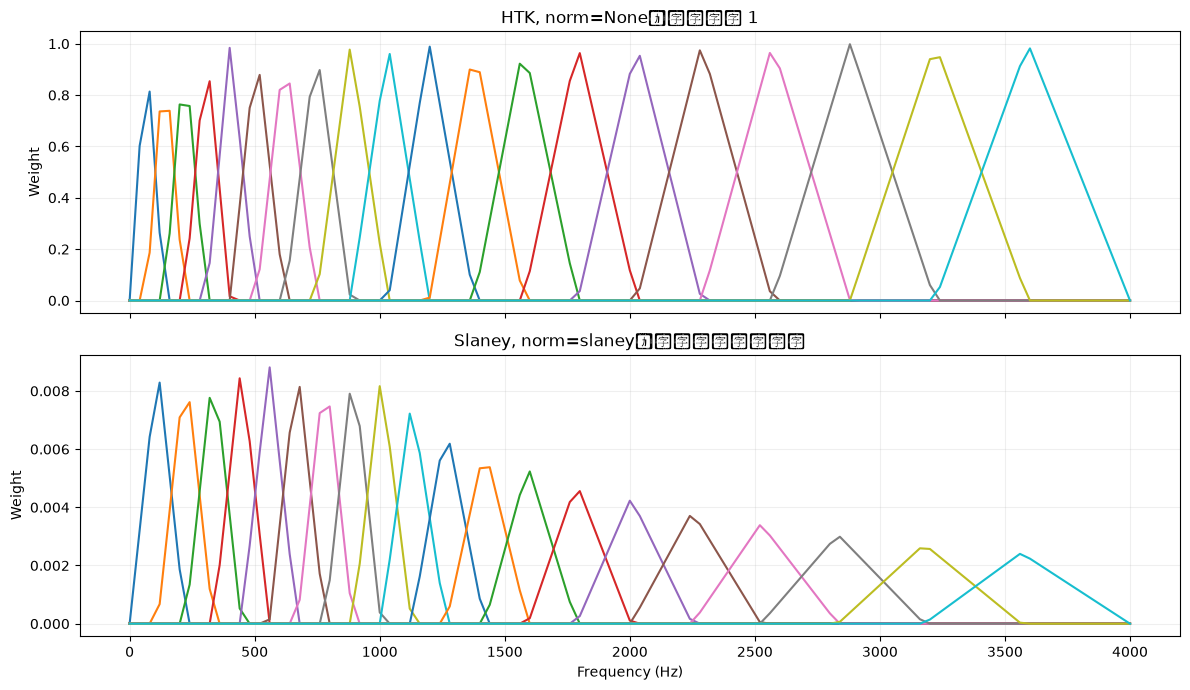

In [9]:
htk_bank=librosa.filters.mel(sr=sr,n_fft=cfg.n_fft,n_mels=20,htk=True,norm=None)
slaney_bank=librosa.filters.mel(sr=sr,n_fft=cfg.n_fft,n_mels=20,htk=False,norm='slaney')
freqs=np.fft.rfftfreq(cfg.n_fft,1/sr)
fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
for row in htk_bank: axes[0].plot(freqs,row)
axes[0].set_title('HTK, norm=None：峰值接近 1')
for row in slaney_bank: axes[1].plot(freqs,row)
axes[1].set_title('Slaney, norm=slaney：按频带宽度归一化')
for ax in axes: ax.set_ylabel('Weight'); ax.grid(alpha=0.2)
axes[1].set_xlabel('Frequency (Hz)'); plt.tight_layout(); plt.show()

## 8. `power=1` 与 `power=2`

`power=1` 使用 magnitude，`power=2` 使用 magnitude²，也就是功率谱。随后转换 dB 时，幅度用 `20*log10`，功率用 `10*log10`。混用会造成尺度错误。

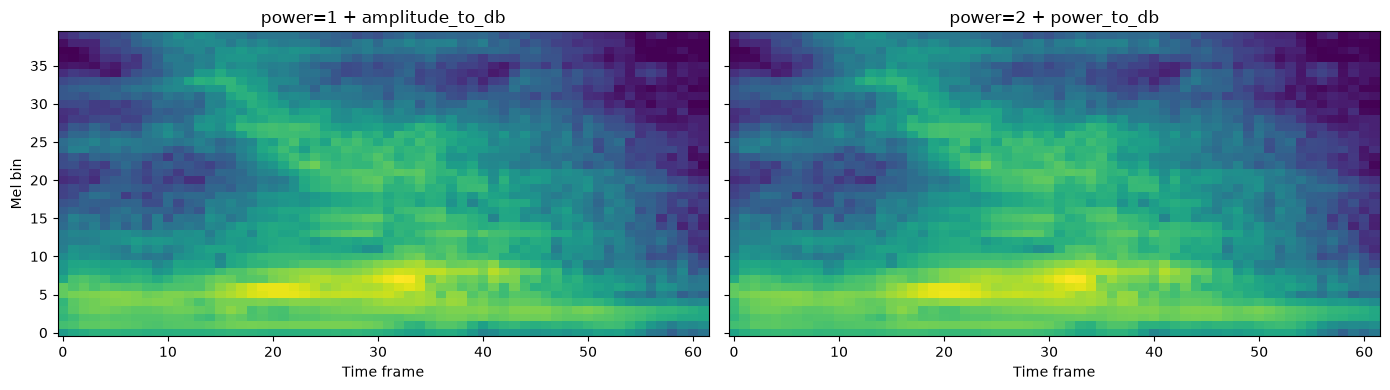

In [10]:
magnitude_mel=librosa.feature.melspectrogram(y=audio,sr=sr,n_fft=200,hop_length=80,win_length=200,center=False,power=1,n_mels=40)
power_mel=librosa.feature.melspectrogram(y=audio,sr=sr,n_fft=200,hop_length=80,win_length=200,center=False,power=2,n_mels=40)
magnitude_db=librosa.amplitude_to_db(magnitude_mel,ref=np.max)
power_db=librosa.power_to_db(power_mel,ref=np.max)
fig,axes=plt.subplots(1,2,figsize=(14,4),sharex=True,sharey=True)
axes[0].imshow(magnitude_db,origin='lower',aspect='auto',vmin=-80,vmax=0); axes[0].set_title('power=1 + amplitude_to_db')
axes[1].imshow(power_db,origin='lower',aspect='auto',vmin=-80,vmax=0); axes[1].set_title('power=2 + power_to_db')
for ax in axes: ax.set_xlabel('Time frame')
axes[0].set_ylabel('Mel bin'); plt.tight_layout(); plt.show()

## 9. 一个更实用的 Librosa 前端

下面使用常见参数：8 kHz 音频、25 ms 窗、10 ms hop、256 点 FFT、40 Mel bins、`center=False`。生产项目应将配置和模型一起保存。

In [11]:
@dataclass(frozen=True)
class LibrosaFrontendConfig:
    sample_rate:int=8000
    n_fft:int=256
    win_length:int=200
    hop_length:int=80
    n_mels:int=40
    fmin:float=0.0
    fmax:float|None=None
    center:bool=False

def extract_logmel_librosa(audio,cfg):
    if audio.ndim!=1: raise ValueError('audio 必须是 mono 一维数组')
    mel=librosa.feature.melspectrogram(
        y=audio,sr=cfg.sample_rate,n_fft=cfg.n_fft,win_length=cfg.win_length,
        hop_length=cfg.hop_length,n_mels=cfg.n_mels,fmin=cfg.fmin,fmax=cfg.fmax,
        center=cfg.center,window='hann',power=2.0)
    db=librosa.power_to_db(mel,ref=np.max,top_db=80)
    return db.T.astype(np.float32)  # (time, mel)

production_cfg=LibrosaFrontendConfig()
feature=extract_logmel_librosa(audio,production_cfg)
print('feature shape:',feature.shape)
print('dtype:',feature.dtype)
print('range:',float(feature.min()),float(feature.max()))
assert feature.ndim==2
assert feature.shape[1]==production_cfg.n_mels
assert np.isfinite(feature).all()

feature shape: (62, 40)
dtype: float32
range: -80.0 0.0


## 10. 参数实验：一次只改一个参数


In [12]:
def compare_parameter(n_mels=40,center=False,power=2):
    mel=librosa.feature.melspectrogram(y=audio,sr=sr,n_fft=256,win_length=200,hop_length=80,
        n_mels=n_mels,center=center,power=power)
    db=librosa.amplitude_to_db(mel,ref=np.max) if power==1 else librosa.power_to_db(mel,ref=np.max)
    plt.figure(figsize=(11,4)); plt.imshow(db,origin='lower',aspect='auto',vmin=-80,vmax=0,cmap='magma')
    plt.xlabel('Time frame'); plt.ylabel('Mel bin')
    plt.title(f'n_mels={n_mels}, center={center}, power={power}, shape={db.shape}')
    plt.colorbar(label='Relative dB'); plt.show()
widgets.interact(compare_parameter,
    n_mels=widgets.IntSlider(value=40,min=20,max=100,step=20,description='Mel bins'),
    center=widgets.Checkbox(value=False,description='center'),
    power=widgets.Dropdown(options=[1,2],value=2,description='power'))

interactive(children=(IntSlider(value=40, description='Mel bins', min=20, step=20), Checkbox(value=False, desc…

<function __main__.compare_parameter(n_mels=40, center=False, power=2)>

## 调试清单

当两个 Log-Mel 结果不同时，按顺序检查：

1. 输入采样率、声道、dtype、幅度范围。
2. frame/win length 与 hop length。
3. n_fft 和 zero padding 的位置。
4. center 与 pad_mode。
5. Hann 是对称窗还是周期窗。
6. magnitude 还是 power。
7. HTK 还是 Slaney Mel。
8. Mel filterbank 是否归一化。
9. ln、log10 还是 dB。
10. reference、epsilon、top_db。
11. 输出是 `(time,mel)` 还是 `(mel,time)`。

## 本课测试

1. 为什么需要配置对象？
2. Librosa 的 Mel 输出维度顺序是什么？我们为什么转置？
3. `center=True` 和 `center=False` 的帧定位有什么区别？
4. 为什么流式 ASR 常使用 `center=False`？
5. `power=1` 和 `power=2` 分别代表什么？
6. 为什么功率转 dB 用 10，而幅度转 dB 用 20？
7. HTK 与 Slaney Mel 是否必然给出相同数值？
8. `norm='slaney'` 大致做什么？
9. 两个实现 shape 一样但数值不同，应检查哪些参数？至少写五项。
10. `top_db=80` 表示什么？
11. 为什么要检查 `np.isfinite(feature).all()`？
12. 模型训练和推理为什么必须使用同一套前端参数？

参考答案：1 集中记录并复现参数；2 `(mel,time)`，模型常用 `(time,mel)`；3 居中帧并 padding/从帧起点直接切；4 不能依赖未来样本；5 magnitude/power；6 功率与振幅平方关系；7 不会；8 按频带宽度做面积归一化；9 见调试清单；10 截断到峰值以下最多 80 dB；11 防止 log(0)、NaN、Inf 进入模型；12 否则输入分布和 shape 可能改变。

## 小结

这一课最重要的不是记住 Librosa 参数，而是学会：

`固定配置 → 检查输入 → 提取特征 → 检查 shape/dtype/range → 与参考实现对齐 → 定位默认参数差异`

下一课：把多个不同长度音频组成 batch，学习 padding、length、mask，以及 ASR 模型为什么必须知道哪些帧是真实语音、哪些帧只是补零。

<!-- course-upgrade-v2 -->
## 强化练习：第 6 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `声学前端封装`、`数值一致性`、`参数契约`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**手写前端与 librosa 出现一帧差异**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**为前端写 shape、范围和误差断言**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**把前端输出契约交给第 7 课 batch**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：声学前端封装、数值一致性、参数契约。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 声学前端封装、数值一致性、参数契约。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
